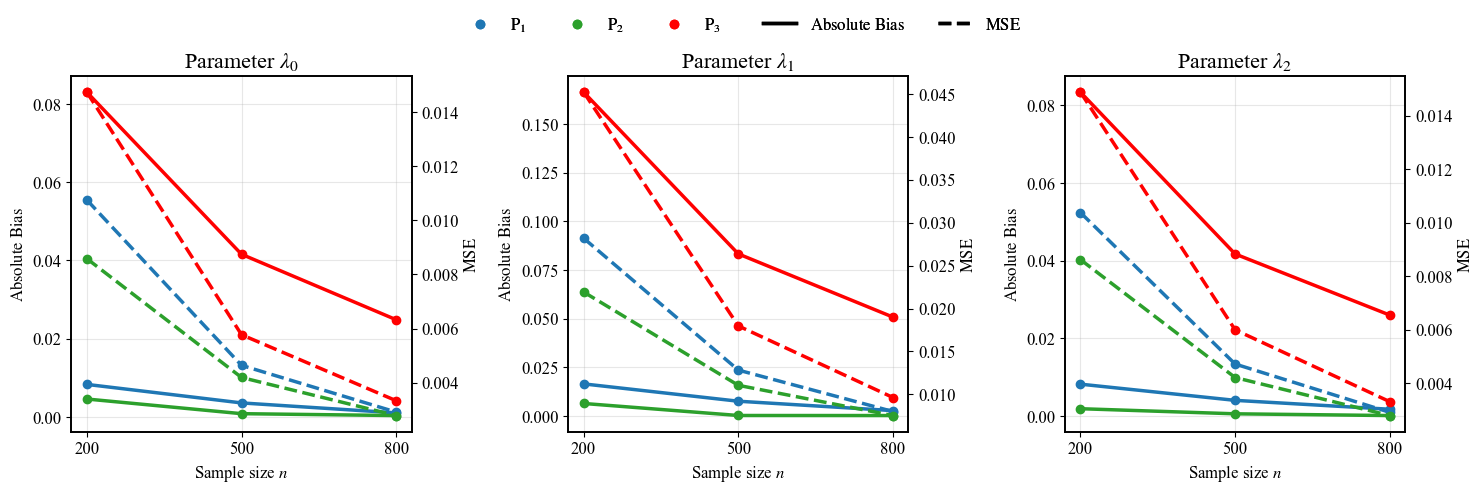

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.lines import Line2D

# ======================
# Academic plotting style
# ======================
def set_academic_style():
    plt.style.use('default')
    rcParams['font.family'] = 'serif'
    rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
    rcParams['mathtext.fontset'] = 'stix'
    rcParams['font.size'] = 12
    rcParams['axes.labelsize'] = 14
    rcParams['axes.titlesize'] = 16
    rcParams['xtick.labelsize'] = 12
    rcParams['ytick.labelsize'] = 12
    rcParams['legend.fontsize'] = 12
    rcParams['figure.figsize'] = (15, 5)   # 1x3 子图
    rcParams['figure.dpi'] = 100
    rcParams['savefig.dpi'] = 300
    rcParams['axes.linewidth'] = 1.2
    rcParams['lines.linewidth'] = 2.5
    rcParams['grid.linewidth'] = 0.8
    rcParams['grid.alpha'] = 0.25
    rcParams['axes.edgecolor'] = 'black'
    rcParams['axes.labelcolor'] = 'black'
    rcParams['xtick.color'] = 'black'
    rcParams['ytick.color'] = 'black'

set_academic_style()

# ======================
# Load data
# ======================
df = pd.read_csv(r'C:\Users\user\Desktop\S1\simulation_results_parallel.csv')

# Only the three parameters for this figure
params = ["lambda0", "lambda1", "lambda2"]
param_titles = { "lambda0": r"Parameter $\lambda_{0}$",
                 "lambda1": r"Parameter $\lambda_{1}$",
                 "lambda2": r"Parameter $\lambda_{2}$" }

# Prior color map (consistent, high-contrast)
prior_order = ["P1", "P2", "P3"]
prior_labels = {
    "P1": r"$\mathrm{P}_1$",
    "P2": r"$\mathrm{P}_2$", 
    "P3": r"$\mathrm{P}_3$"
}
prior_colors = {
    "P1": "#1f77b4",   # blue
    "P2": "#2ca02c",   # orange
    "P3": "#ff0000",   # green
}

# ======================
# Create 1x3 subplots
# ======================
fig, axes = plt.subplots(1, 3, sharex=True)

for ax, param in zip(axes, params):
    sub = df[df["parameter"] == param].copy()
    # Ensure x ticks are ordered and complete
    # If multiple scenarios exist, average them (optional, robust)
    sub = (sub.groupby(["n", "prior"], as_index=False)
               .agg(bias=("bias", "mean"),
                    mse=("mse", "mean")))

    # Left axis: |Bias|
    ax1 = ax
    # Right axis: MSE (log scale)
    ax2 = ax1.twinx()

    # X ticks
    x_vals = sorted(sub["n"].unique().tolist())
    ax1.set_xticks(x_vals)
    ax1.set_xlabel(r"Sample size $n$")

    # Plot by prior: same color, solid for |Bias|, dashed for MSE
    for pr in prior_order:
        tmp = sub[sub["prior"] == pr].sort_values("n")
        if tmp.empty:
            continue

        # |Bias| — solid
        ax1.plot(
            tmp["n"], np.abs(tmp["bias"]),
            color=prior_colors[pr],
            linestyle='-',
            marker='o',
            label=f"{pr} — Bias"
        )

        # MSE — dashed (log scale on right axis)
        ax2.plot(
            tmp["n"], tmp["mse"],
            color=prior_colors[pr],
            linestyle='--',
            marker='o',
            label=f"{pr} — MSE"
        )

    # Axis labels
    ax1.set_ylabel(r"$\mathrm{Absolute \ Bias}$")
    ax2.set_ylabel(r"$\mathrm{MSE}$")

    # Title
    ax1.set_title(param_titles[param])

    # Grid on left axis for a clean academic look
    ax1.grid(True, alpha=0.3)

# --------
# Construct a clean, explicit legend (colors = priors; line styles = metrics)
# --------
color_legend_elements = [
    Line2D([0], [0], color=prior_colors[pr], linestyle='none', marker='o', label=prior_labels[pr])
    for pr in prior_order
]

# 创建线型图例（指标）
line_legend_elements = [
    Line2D([0], [0], color='black', linestyle='-', lw=2.5, label=r'$\mathrm{Absolute \ Bias}$'),
    Line2D([0], [0], color='black', linestyle='--', lw=2.5, label=r'$\mathrm{MSE}$')
]

# 创建两个图例并排显示
legend1 = fig.legend(handles=color_legend_elements, loc='upper center', 
                    ncol=3, frameon=False, bbox_to_anchor=(0.4, 1))
legend2 = fig.legend(handles=line_legend_elements, loc='upper center', 
                    ncol=2, frameon=False, bbox_to_anchor=(0.6, 1))

# 将两个图例添加到图形中
fig.add_artist(legend1)
fig.add_artist(legend2)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()


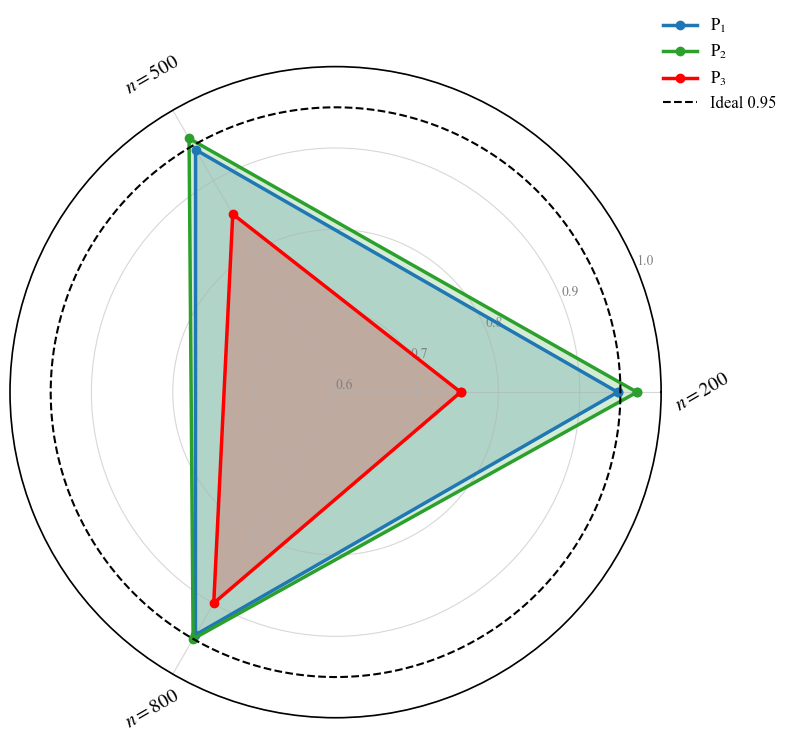

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

def set_academic_style():
    plt.style.use('default')
    rcParams['font.family'] = 'serif'
    rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
    rcParams['mathtext.fontset'] = 'stix'
    rcParams['font.size'] = 12
    rcParams['axes.labelsize'] = 14
    rcParams['axes.titlesize'] = 16
    rcParams['xtick.labelsize'] = 12
    rcParams['ytick.labelsize'] = 12
    rcParams['legend.fontsize'] = 12
    rcParams['figure.figsize'] = (8, 8)
    rcParams['figure.dpi'] = 100
    rcParams['savefig.dpi'] = 300
    rcParams['axes.linewidth'] = 1.2
    rcParams['lines.linewidth'] = 2.5
    rcParams['grid.linewidth'] = 0.8
    rcParams['grid.alpha'] = 0.25

set_academic_style()

params = ["lambda0", "lambda1", "lambda2"]
prior_order = ["P1", "P2", "P3"]
prior_colors = {
    "P1": "#1f77b4",   # blue
    "P2": "#2ca02c",   # orange
    "P3": "#ff0000",   # green
}

# 计算覆盖率平均值
avg_cov = (df[df["parameter"].isin(params)]
             .groupby(["prior", "n"], as_index=False)
             .agg(coverage=("coverage", "mean")))

sample_sizes = [200, 500, 800]
N = len(sample_sizes)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=(8,8))

for pr in prior_order:
    subset = avg_cov[avg_cov["prior"] == pr].sort_values("n")
    values = subset["coverage"].tolist()
    values += values[:1]
    ax.plot(angles, values, color=prior_colors[pr], linestyle='-', marker='o', linewidth=2.5, label=prior_labels[pr])
    ax.fill(angles, values, color=prior_colors[pr], alpha=0.2)

ax.set_xticks(angles[:-1])
# ax.set_xticklabels([fr"$n={n}$" for n in sample_sizes], fontsize=14, y=0.05)
ax.set_xticklabels([])
for ang, n in zip(angles[:-1], sample_sizes):
    ax.text(ang, 1.05, f"$n={n}$",
            rotation=30,           # 水平文字
            ha='center', va='center',
            fontsize=14)



# 缩放半径范围 [0.6, 1.0]
ax.set_ylim(0.6, 1.0)
ax.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels([f"{y:.1f}" for y in [0.6, 0.7, 0.8, 0.9, 1.0]], fontsize=10, color="grey")
ax.grid(True, alpha=0.5)

# 理想覆盖率 0.95
ax.plot(np.linspace(0, 2*np.pi, 500), [0.95]*500, color="black", linestyle="--", linewidth=1.5, label="Ideal 0.95")

ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1), frameon=False, fontsize=12)

plt.tight_layout()
plt.show()


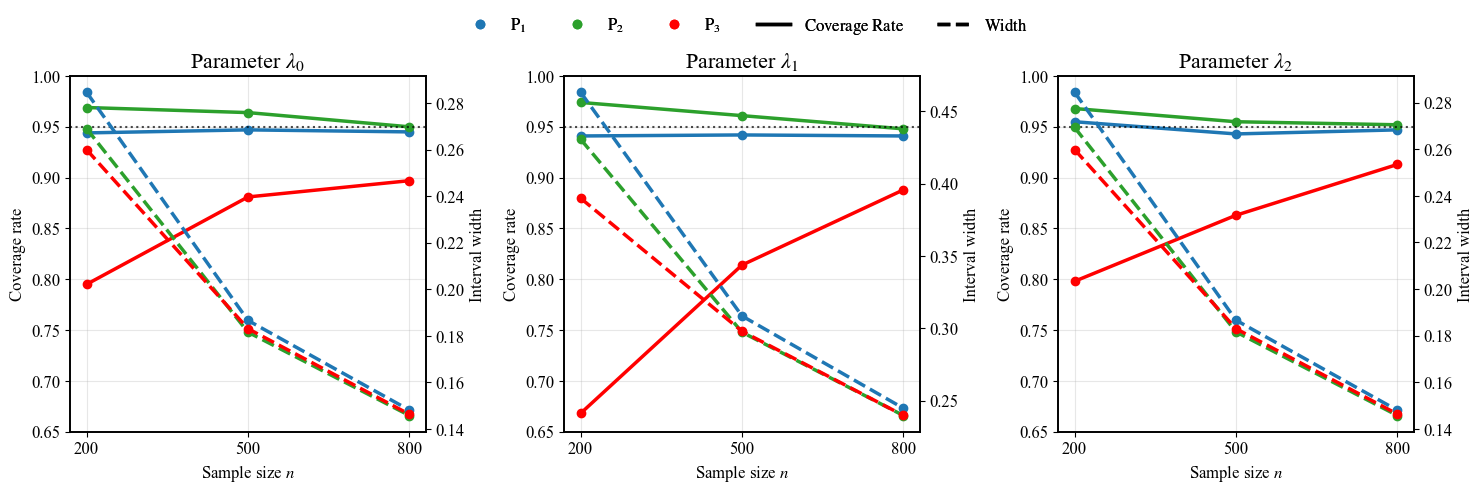

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.lines import Line2D

def set_academic_style():
    plt.style.use('default')
    rcParams['font.family'] = 'serif'
    rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
    rcParams['mathtext.fontset'] = 'stix'
    rcParams['font.size'] = 12
    rcParams['axes.labelsize'] = 14
    rcParams['axes.titlesize'] = 16
    rcParams['xtick.labelsize'] = 12
    rcParams['ytick.labelsize'] = 12
    rcParams['legend.fontsize'] = 12
    rcParams['figure.figsize'] = (15, 5)
    rcParams['figure.dpi'] = 100
    rcParams['savefig.dpi'] = 300
    rcParams['axes.linewidth'] = 1.2
    rcParams['lines.linewidth'] = 2.5
    rcParams['grid.linewidth'] = 0.8
    rcParams['grid.alpha'] = 0.25

set_academic_style()

params = ["lambda0", "lambda1", "lambda2"]
param_titles = { "lambda0": r"Parameter $\lambda_{0}$",
                 "lambda1": r"Parameter $\lambda_{1}$",
                 "lambda2": r"Parameter $\lambda_{2}$" }
prior_order = ["P1", "P2", "P3"]
prior_colors = {
    "P1": "#1f77b4",   # blue
    "P2": "#2ca02c",   # orange
    "P3": "#ff0000",   # green
}

fig, axes = plt.subplots(1, 3, sharex=True, figsize=(15,5))

for ax, param in zip(axes, params):
    sub = df[df["parameter"] == param].copy()
    # 聚合均值和标准差
    sub_stats = (sub.groupby(["n", "prior"], as_index=False)
                    .agg(coverage_mean=("coverage", "mean"),
                         coverage_std=("coverage", "std"),
                         width_mean=("width", "mean"),
                         width_std=("width", "std")))

    ax1 = ax
    ax2 = ax1.twinx()
    x_vals = sorted(sub_stats["n"].unique().tolist())
    ax1.set_xticks(x_vals)
    ax1.set_xlabel(r"Sample size $n$")

    for pr in prior_order:
        tmp = sub_stats[sub_stats["prior"] == pr].sort_values("n")
        if tmp.empty: continue

        # Coverage: 实线 + 误差带
        ax1.plot(tmp["n"], tmp["coverage_mean"], color=prior_colors[pr], linestyle="-", marker="o", label=f"{pr} — Coverage")

        # Width: 虚线
        ax2.plot(tmp["n"], tmp["width_mean"], color=prior_colors[pr], linestyle="--", marker='o', label=f"{pr} — Width")

    ax1.set_ylabel(r"Coverage rate")
    ax2.set_ylabel(r"Interval width")

    # 覆盖率范围缩放到 [0.6, 1.0]，突出趋势
    ax1.set_ylim(0.65, 1.0)
    ax1.axhline(0.95, color="black", linestyle=":", linewidth=1.5, alpha=0.7)

    ax1.set_title(param_titles[param])
    ax1.grid(True, alpha=0.3)

# 图例
color_legend_elements = [
    Line2D([0], [0], color=prior_colors[pr], linestyle='none', marker='o', lw=2.5, label=prior_labels[pr])
    for pr in prior_order
]

# 创建线型图例（指标）
line_legend_elements = [
    Line2D([0], [0], color='black', linestyle='-', lw=2.5, label=r'$\mathrm{Coverage \ Rate}$'),
    Line2D([0], [0], color='black', linestyle='--', lw=2.5, label=r'$\mathrm{Width}$')
]

# 创建两个图例并排显示
legend1 = fig.legend(handles=color_legend_elements, loc='upper center', 
                    ncol=3, frameon=False, bbox_to_anchor=(0.4, 1))
legend2 = fig.legend(handles=line_legend_elements, loc='upper center', 
                    ncol=2, frameon=False, bbox_to_anchor=(0.6, 1))

# 将两个图例添加到图形中
fig.add_artist(legend1)
fig.add_artist(legend2)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()


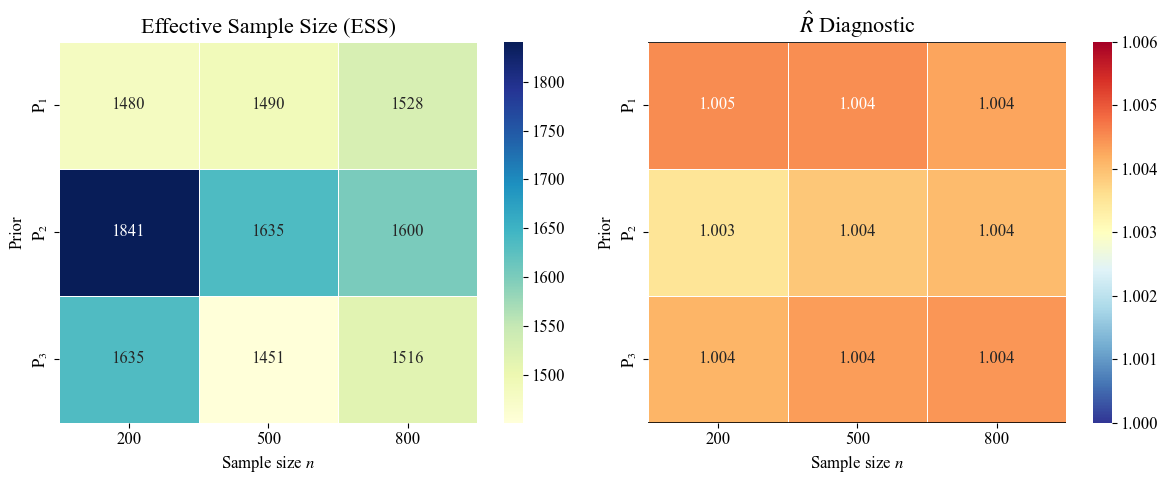

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

def set_academic_style():
    plt.style.use('default')
    rcParams['font.family'] = 'serif'
    rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
    rcParams['mathtext.fontset'] = 'stix'
    rcParams['font.size'] = 12
    rcParams['axes.labelsize'] = 14
    rcParams['axes.titlesize'] = 16
    rcParams['xtick.labelsize'] = 12
    rcParams['ytick.labelsize'] = 12
    rcParams['legend.fontsize'] = 12
    rcParams['figure.figsize'] = (12, 5)
    rcParams['figure.dpi'] = 100
    rcParams['savefig.dpi'] = 300
    rcParams['axes.linewidth'] = 1.2

set_academic_style()

# 计算每种情况的平均 ESS 和 Rhat
stats = (df.groupby(["prior", "n"], as_index=False)
           .agg(ESS=("ess", "mean"), Rhat=("rhat", "mean")))

stats['prior_label'] = stats['prior'].map(prior_labels)

# 透视表，行=prior，列=n
ESS_pivot = stats.pivot(index="prior_label", columns="n", values="ESS")
Rhat_pivot = stats.pivot(index="prior_label", columns="n", values="Rhat")

# 创建子图
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ESS 热图
sns.heatmap(ESS_pivot, annot=True, fmt=".0f", cmap="YlGnBu",
            cbar=True, ax=axes[0], linewidths=0.5, linecolor='white')
axes[0].set_title("Effective Sample Size (ESS)")
axes[0].set_xlabel(r"Sample size $n$")
axes[0].set_ylabel("Prior")

# R-hat 热图
sns.heatmap(Rhat_pivot, annot=True, fmt=".3f", cmap="RdYlBu_r",
            cbar=True, ax=axes[1], linewidths=0.5, linecolor='white',
            vmin=1, vmax=1.006)  # 限制颜色范围
axes[1].set_title(r"$\hat{R}$ Diagnostic")
axes[1].set_xlabel(r"Sample size $n$")
axes[1].set_ylabel("Prior")

# 为 R-hat 添加参考线 (1.05)
axes[1].axhline(y=0, color="black", linewidth=1.2)  # 热图从上往下排列
axes[1].axhline(y=len(Rhat_pivot.index), color="black", linewidth=1.2)

plt.tight_layout()
plt.show()

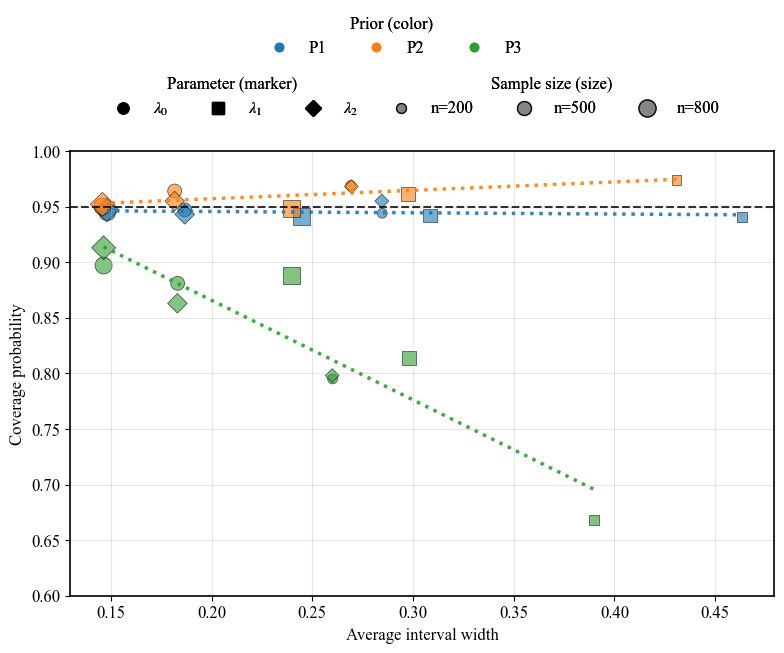

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.lines import Line2D

def set_academic_style():
    plt.style.use('default')
    rcParams['font.family'] = 'serif'
    rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
    rcParams['mathtext.fontset'] = 'stix'
    rcParams['font.size'] = 12
    rcParams['axes.labelsize'] = 14
    rcParams['axes.titlesize'] = 16
    rcParams['xtick.labelsize'] = 12
    rcParams['ytick.labelsize'] = 12
    rcParams['legend.fontsize'] = 12
    rcParams['figure.figsize'] = (8, 6)
    rcParams['figure.dpi'] = 100
    rcParams['savefig.dpi'] = 300
    rcParams['axes.linewidth'] = 1.2
    rcParams['lines.linewidth'] = 2
    rcParams['grid.linewidth'] = 0.8
    rcParams['grid.alpha'] = 0.25

set_academic_style()

# 先按 (prior, n, parameter) 聚合（如果文件已是均值，此步等价于整理）
agg = (df.groupby(["prior", "n", "parameter"], as_index=False)
         .agg(width=("width","mean"),
              coverage=("coverage","mean")))

prior_colors = {"P1": "#1f77b4", "P2": "#ff7f0e", "P3": "#2ca02c"}
param_markers = {"lambda0": "o", "lambda1": "s", "lambda2": "D"}
size_map = {200:50, 500:100, 800:150}  # 样本量→点大小

fig, ax = plt.subplots(figsize=(8,6))

# 散点
for pr, c in prior_colors.items():
    sub_pr = agg[agg["prior"]==pr]
    for param, mk in param_markers.items():
        sub = sub_pr[sub_pr["parameter"]==param]
        if sub.empty: continue
        ax.scatter(sub["width"], sub["coverage"],
                   s=sub["n"].map(size_map),
                   color=c, marker=mk, alpha=0.6,
                   edgecolor="black", linewidth=0.6)

# 趋势线（按先验）
for pr, c in prior_colors.items():
    sp = agg[agg["prior"]==pr]
    if len(sp) >= 2:
        x = sp["width"].values
        y = sp["coverage"].values
        coef = np.polyfit(x, y, deg=1)   # 线性趋势
        xs = np.linspace(x.min(), x.max(), 100)
        ys = np.polyval(coef, xs)
        ax.plot(xs, ys, color=c, linestyle=":", linewidth=2.5, alpha=0.9)

# 参考线 y=0.95
ax.axhline(0.95, color="black", linestyle="--", linewidth=1.5, alpha=0.8)

ax.set_xlabel("Average interval width")
ax.set_ylabel("Coverage probability")
ax.set_ylim(0.6, 1.0)
ax.grid(True, alpha=0.3)

# —— 正确的三段式图例：颜色=先验；形状=参数；大小=样本量
fig.subplots_adjust(top=0.80)

# 先验（颜色）
handles_prior = [Line2D([0],[0], color=prior_colors[p], marker='o', linestyle='none', lw=2, label=p) 
                 for p in ["P1","P2","P3"]]
leg1 = fig.legend(handles=handles_prior, title="Prior (color)",
                  loc="upper center", bbox_to_anchor=(0.5, 1.1), ncol=3, frameon=False)

# 参数（形状）
handles_param = [Line2D([0],[0], color="black", marker=param_markers[p], linestyle='None', 
                        markersize=8, label=rf"$\lambda_{{{i}}}$")
                 for i, p in enumerate(["lambda0","lambda1","lambda2"])]
leg2 = fig.legend(handles=handles_param, title="Parameter (marker)",
                  loc="upper center", bbox_to_anchor=(0.3, 1), ncol=3, frameon=False)

# 样本量（大小）
size_handles = [plt.scatter([], [], s=size_map[n], edgecolor="black", facecolor="gray", alpha=0.8, label=f"n={n}")
                for n in [200, 500, 800]]
leg3 = fig.legend(handles=size_handles, title="Sample size (size)",
                  loc="upper center", bbox_to_anchor=(0.7, 1), ncol=3, frameon=False)

ax.add_artist(leg1); ax.add_artist(leg2); ax.add_artist(leg3)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()
